<a href="https://colab.research.google.com/github/subod4/ADdetection/blob/main/alzhe2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Diagnosis - Complete Improved Pipeline

Based on your original code but with ALL critical improvements:
1. Segmentation usage (extracts only PAR segments)
2. Data augmentation (multiplies dataset)
3. Proper train/val/test split
4. Standardized segment lengths
5. K-fold cross-validation option
6. Test predictions for submission

In [1]:
!pip install gdown
import gdown

!gdown --fuzzy "https://drive.google.com/file/d/1HotQ4CPoHHD-q9y_IVsW8kEEHS78365G/view?usp=sharing" -O /content/train.rar
!gdown --fuzzy "https://drive.google.com/file/d/1jMAH8EpL2vldBRK7jpE1Ln8Ly6occ1Qk/view?usp=sharing" -O /content/test-dist.rar
!unrar x /content/train.rar
!unrar x /content/test-dist

Downloading...
From (original): https://drive.google.com/uc?id=1HotQ4CPoHHD-q9y_IVsW8kEEHS78365G
From (redirected): https://drive.google.com/uc?id=1HotQ4CPoHHD-q9y_IVsW8kEEHS78365G&confirm=t&uuid=f71b04b5-caed-41be-b839-4662d85ee1e7
To: /content/train.rar
100% 997M/997M [00:14<00:00, 68.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1jMAH8EpL2vldBRK7jpE1Ln8Ly6occ1Qk
From (redirected): https://drive.google.com/uc?id=1jMAH8EpL2vldBRK7jpE1Ln8Ly6occ1Qk&confirm=t&uuid=45865cbf-26a7-48cc-bbdf-2b6e8d70df7e
To: /content/test-dist.rar
100% 235M/235M [00:04<00:00, 48.2MB/s]

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/train.rar

Creating    train                                                     OK
Extracting  train/adresso-train-mmse-scores.csv                            0%  OK 
Creating    train/audio                                               OK
Creating    train/audio/ad                              

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from collections import Counter
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*80)
print("ALZHEIMER'S DISEASE DIAGNOSIS - COMPLETE IMPROVED PIPELINE")
print("="*80)

ALZHEIMER'S DISEASE DIAGNOSIS - COMPLETE IMPROVED PIPELINE


## Configuration

In [3]:
CONFIG = {
    'sr': 16000,                    # Sample rate
    'segment_duration': 3.0,        # Standardize segments to 3 seconds (try 4-5s for more context)
    'min_segment_duration': 1.0,    # Minimum segment length to keep
    'n_mels': 128,                  # Number of mel bands
    'fmax': 8000,                   # Maximum frequency
    'use_augmentation': True,       # Enable data augmentation
    'use_spec_augment': True,       # NEW: Enable SpecAugment on mel spectrograms
    'use_kfold': True,              # Use K-fold cross-validation
    'n_folds': 5,                   # Number of folds for cross-validation
    'epochs': 50,                   # Maximum epochs
    'batch_size': 32,               # Batch size
    'learning_rate': 0.0005,        # Learning rate
    'max_segments_per_file': 30,    # NEW: Cap segments per file (file-balanced sampling)
    'test_folder': 'test-dist/audio',
    'test_seg_folder': 'test-dist/segmentation'  # Test segmentation folder
}

## 1. Data Loading with Segmentation (CRITICAL IMPROVEMENT!)

This is THE KEY improvement - we extract only patient speech (PAR segments)!

In [4]:
def augment_audio(y, sr=16000):
    """
    Apply data augmentation to increase dataset diversity.
    Returns list of augmented versions.
    IMPROVED: Reduced pitch shift range (can destroy clinical cues)
    """
    augmented = [y]  # Original

    # Time stretching (95-105% speed) - more conservative
    if np.random.rand() > 0.5:
        rate = np.random.uniform(0.95, 1.05)
        y_stretch = librosa.effects.time_stretch(y, rate=rate)
        if len(y_stretch) < len(y):
            y_stretch = np.pad(y_stretch, (0, len(y) - len(y_stretch)))
        else:
            y_stretch = y_stretch[:len(y)]
        augmented.append(y_stretch)

    # Pitch shifting - REDUCED range (-1 to +1 semitones) to preserve speech cues
    if np.random.rand() > 0.7:  # Less frequent
        n_steps = np.random.choice([-1, 1])  # Small shifts only
        y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
        augmented.append(y_pitch)

    # Add subtle noise
    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 0.003, y.shape)
        y_noise = y + noise
        y_noise = librosa.util.normalize(y_noise)
        augmented.append(y_noise)

    return augmented

def spec_augment(mel_spec, freq_mask_param=15, time_mask_param=20, num_masks=2):
    """
    SpecAugment: Apply frequency and time masking to mel spectrogram.
    More effective than raw audio augmentation for speech tasks.

    Args:
        mel_spec: Mel spectrogram (n_mels, time_frames)
        freq_mask_param: Maximum frequency mask width
        time_mask_param: Maximum time mask width
        num_masks: Number of masks to apply for each type
    """
    augmented = mel_spec.copy()
    n_mels, n_frames = augmented.shape

    # Frequency masking
    for _ in range(num_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(1, n_mels - f))
        augmented[f0:f0 + f, :] = 0

    # Time masking
    for _ in range(num_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(1, n_frames - t))
        augmented[:, t0:t0 + t] = 0

    return augmented

def get_file_list(audio_folder, seg_folder):
    """
    Get list of (audio_path, seg_path, filename) tuples for all valid files.
    This is used for file-level splitting BEFORE segment extraction.
    """
    file_list = []
    audio_files = sorted([f for f in os.listdir(audio_folder) if f.endswith('.wav')])

    for filename in audio_files:
        audio_path = os.path.join(audio_folder, filename)
        seg_path = os.path.join(seg_folder, filename.replace('.wav', '.csv'))

        if os.path.exists(seg_path):
            file_list.append((audio_path, seg_path, filename))
        else:
            print(f"  Warning: No segmentation for {filename}")

    return file_list

def extract_segments_from_file(audio_path, seg_path, label, sr=16000,
                                speaker='PAR', min_duration=1.0, max_segments_per_file=None):
    """
    Extract PAR segments from a SINGLE audio file.
    NO augmentation here - augmentation is applied separately after split.

    Args:
        max_segments_per_file: Cap segments per file to prevent long files dominating (None = no limit)
    """
    segments = []

    try:
        seg_df = pd.read_csv(seg_path)
        y_full, _ = librosa.load(audio_path, sr=sr)

        par_segments = seg_df[seg_df['speaker'] == speaker]

        for _, row in par_segments.iterrows():
            begin_sample = int(row['begin'] * sr / 1000)
            end_sample = int(row['end'] * sr / 1000)

            segment = y_full[begin_sample:end_sample]

            if len(segment) > sr * min_duration:
                segment = librosa.util.normalize(segment)
                segments.append((segment, label))

        # Cap segments per file if specified (file-balanced sampling)
        if max_segments_per_file is not None and len(segments) > max_segments_per_file:
            np.random.shuffle(segments)
            segments = segments[:max_segments_per_file]

    except Exception as e:
        print(f"  Error processing {os.path.basename(audio_path)}: {e}")

    return segments

def extract_segments_with_file_tracking(file_list, label, sr=16000, min_duration=1.0,
                                        augment=False, max_segments_per_file=None):
    """
    Extract segments from files WITH filename tracking for GroupKFold.
    Returns: (segments, labels, file_groups) where file_groups maps each segment to its source file.

    This is CRITICAL for proper cross-validation without data leakage.
    """
    all_segments = []
    all_labels = []
    all_file_groups = []  # Track which file each segment came from

    for audio_path, seg_path, filename in file_list:
        segments = extract_segments_from_file(
            audio_path, seg_path, label, sr, min_duration=min_duration,
            max_segments_per_file=max_segments_per_file
        )

        # Apply augmentation ONLY for training data
        if augment:
            augmented_segments = []
            for segment, lbl in segments:
                aug_versions = augment_audio(segment, sr)
                for aug_seg in aug_versions:
                    augmented_segments.append((aug_seg, lbl))
                    all_file_groups.append(filename)  # All augmented versions map to same file
            all_segments.extend([s[0] for s in augmented_segments])
            all_labels.extend([s[1] for s in augmented_segments])
        else:
            all_segments.extend([s[0] for s in segments])
            all_labels.extend([s[1] for s in segments])
            all_file_groups.extend([filename] * len(segments))

    return all_segments, all_labels, all_file_groups

def extract_segments_from_files(file_list, label, sr=16000, min_duration=1.0, augment=False):
    """
    Extract segments from a list of files (legacy interface).
    Augmentation is applied ONLY if augment=True (should be True only for training).
    """
    segments, labels, _ = extract_segments_with_file_tracking(
        file_list, label, sr, min_duration, augment
    )
    return list(zip(segments, labels))

# Legacy function kept for compatibility (but NOT USED in new pipeline)
def load_segmented_audio(audio_file, seg_file, label, sr=16000,
                        speaker='PAR', min_duration=1.0, augment=False):
    """
    [LEGACY - not used in corrected pipeline]
    Load only participant (PAR) segments from audio file.
    """
    return extract_segments_from_file(audio_file, seg_file, label, sr, speaker, min_duration)

def load_all_segmented_audio(audio_folder, seg_folder, label, augment=False):
    """[LEGACY - not used in corrected pipeline]"""
    file_list = get_file_list(audio_folder, seg_folder)
    return extract_segments_from_files(file_list, label, CONFIG['sr'],
                                       CONFIG['min_segment_duration'], augment)

In [5]:
# ============================================================================
# CORRECTED PIPELINE: Split by FILE first, then extract segments
# This prevents data leakage from same speaker appearing in train AND test
# ============================================================================

print("\n1️⃣  COLLECTING FILE LIST (NO SEGMENTS YET)")
print("-" * 80)

ad_folder = 'train/audio/ad'
cn_folder = 'train/audio/cn'
ad_seg_folder = 'train/segmentation/ad'
cn_seg_folder = 'train/segmentation/cn'

print("Collecting AD (Alzheimer's) files...")
ad_files = get_file_list(ad_folder, ad_seg_folder)
print(f"  ✓ Found {len(ad_files)} AD files")

print("\nCollecting CN (Control) files...")
cn_files = get_file_list(cn_folder, cn_seg_folder)
print(f"  ✓ Found {len(cn_files)} CN files")

# Create file-level dataset (before any segmentation!)
all_files = [(f, 'AD') for f in ad_files] + [(f, 'CN') for f in cn_files]
file_labels = ['AD'] * len(ad_files) + ['CN'] * len(cn_files)

print(f"\n📊 TOTAL FILES: {len(all_files)}")
print(f"   AD: {len(ad_files)} files | CN: {len(cn_files)} files")
print(f"\n⚠️  IMPORTANT: Splitting by FILE first to prevent data leakage!")


1️⃣  COLLECTING FILE LIST (NO SEGMENTS YET)
--------------------------------------------------------------------------------
  ✓ Found 87 AD files

  ✓ Found 79 CN files

📊 TOTAL FILES: 166
   AD: 87 files | CN: 79 files

⚠️  IMPORTANT: Splitting by FILE first to prevent data leakage!


## 2. Split Files FIRST (Prevent Data Leakage!)

In [6]:
print("\n2️⃣  SPLITTING FILES FIRST (CRITICAL: Prevents Data Leakage!)")
print("-" * 80)

# IMPROVED: Combined stratified split (not separate AD/CN splits)
# Build a single dataframe for proper stratified splitting

all_files_data = []
for f in ad_files:
    all_files_data.append({'file_info': f, 'label': 'AD', 'filename': f[2]})
for f in cn_files:
    all_files_data.append({'file_info': f, 'label': 'CN', 'filename': f[2]})

files_df = pd.DataFrame(all_files_data)

# Single stratified split on ALL files
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    files_df,
    test_size=0.20,
    stratify=files_df['label'],  # Stratify by label
    random_state=42
)

# Convert back to list format
train_files = [(row['file_info'], row['label']) for _, row in train_df.iterrows()]
test_files = [(row['file_info'], row['label']) for _, row in test_df.iterrows()]

# Track filenames for test set (needed for file-level evaluation)
test_file_info = {row['filename']: row['label'] for _, row in test_df.iterrows()}

print(f"✓ FILE-LEVEL SPLIT COMPLETE (properly stratified)")
print(f"\n  Training files: {len(train_files)} (AD={len(train_df[train_df['label']=='AD'])}, CN={len(train_df[train_df['label']=='CN'])})")
print(f"  Test files:     {len(test_files)} (AD={len(test_df[test_df['label']=='AD'])}, CN={len(test_df[test_df['label']=='CN'])})")

# Show which files are in test set (for verification)
print(f"\n  Test files: {list(test_file_info.keys())[:5]}...")
print(f"\n⚠️  No file appears in both train AND test - data leakage prevented!")


2️⃣  SPLITTING FILES FIRST (CRITICAL: Prevents Data Leakage!)
--------------------------------------------------------------------------------
✓ FILE-LEVEL SPLIT COMPLETE (properly stratified)

  Training files: 132 (AD=69, CN=63)
  Test files:     34 (AD=18, CN=16)

  Test files: ['adrso300.wav', 'adrso187.wav', 'adrso280.wav', 'adrso299.wav', 'adrso169.wav']...

⚠️  No file appears in both train AND test - data leakage prevented!


## 3. Extract Segments AFTER Split (with Augmentation only for Training)

In [7]:
print("\n3️⃣  EXTRACTING SEGMENTS AFTER SPLIT (WITH FILE TRACKING)")
print("-" * 80)
print("⚠️  Augmentation applied ONLY to training segments!")
print(f"⚠️  Max segments per file: {CONFIG['max_segments_per_file']} (file-balanced sampling)")

# Extract TRAINING segments WITH file tracking (needed for GroupKFold)
print("\nExtracting TRAINING segments (with augmentation and file tracking)...")
train_segments = []
train_labels = []
train_file_groups = []  # CRITICAL: track source file for each segment

for (audio_path, seg_path, filename), label in train_files:
    segments = extract_segments_from_file(
        audio_path, seg_path, label,
        CONFIG['sr'], min_duration=CONFIG['min_segment_duration'],
        max_segments_per_file=CONFIG['max_segments_per_file']  # File-balanced sampling
    )

    # Apply augmentation ONLY to training data
    if CONFIG['use_augmentation']:
        for segment, lbl in segments:
            aug_versions = augment_audio(segment, CONFIG['sr'])
            for aug_seg in aug_versions:
                train_segments.append(aug_seg)
                train_labels.append(lbl)
                train_file_groups.append(filename)  # All augmented versions → same file
    else:
        for segment, lbl in segments:
            train_segments.append(segment)
            train_labels.append(lbl)
            train_file_groups.append(filename)

print(f"  ✓ Training: {len(train_segments)} segments (augmented)")
print(f"  ✓ Unique training files: {len(set(train_file_groups))}")

# Extract TEST segments WITH file tracking (needed for file-level evaluation)
print("\nExtracting TEST segments (NO augmentation, with file tracking)...")
test_segments = []
test_labels = []
test_file_groups = []  # CRITICAL: track source file for file-level eval

for (audio_path, seg_path, filename), label in test_files:
    segments = extract_segments_from_file(
        audio_path, seg_path, label,
        CONFIG['sr'], min_duration=CONFIG['min_segment_duration']
        # No max_segments limit for test - use all segments for aggregation
    )
    for segment, lbl in segments:
        test_segments.append(segment)
        test_labels.append(lbl)
        test_file_groups.append(filename)

print(f"  ✓ Test: {len(test_segments)} segments (no augmentation)")
print(f"  ✓ Unique test files: {len(set(test_file_groups))}")

# Check class distribution
print(f"\n📊 SEGMENT DISTRIBUTION:")
print(f"  Training: AD={train_labels.count('AD')}, CN={train_labels.count('CN')}")
print(f"  Test:     AD={test_labels.count('AD')}, CN={test_labels.count('CN')}")

# Show segments per file distribution
from collections import Counter
train_file_counts = Counter(train_file_groups)
test_file_counts = Counter(test_file_groups)
print(f"\n📊 SEGMENTS PER FILE (Training):")
print(f"  Mean: {np.mean(list(train_file_counts.values())):.1f}, Max: {max(train_file_counts.values())}, Min: {min(train_file_counts.values())}")


3️⃣  EXTRACTING SEGMENTS AFTER SPLIT (WITH FILE TRACKING)
--------------------------------------------------------------------------------
⚠️  Augmentation applied ONLY to training segments!
⚠️  Max segments per file: 30 (file-balanced sampling)

Extracting TRAINING segments (with augmentation and file tracking)...
  ✓ Training: 3748 segments (augmented)
  ✓ Unique training files: 128

Extracting TEST segments (NO augmentation, with file tracking)...
  ✓ Test: 458 segments (no augmentation)
  ✓ Unique test files: 33

📊 SEGMENT DISTRIBUTION:
  Training: AD=1937, CN=1811
  Test:     AD=232, CN=226

📊 SEGMENTS PER FILE (Training):
  Mean: 29.3, Max: 67, Min: 5


## 4. Standardize Lengths and Extract Spectrograms


4️⃣  STANDARDIZING AND EXTRACTING SPECTROGRAMS
--------------------------------------------------------------------------------
Processing training data...
Applying SpecAugment to training spectrograms...
Processing test data...
  ✓ File groups encoded: 128 unique files

✓ Processing complete!
  Spectrogram shape: (128, 94)
  X_train shape: (3748, 128, 94, 1)
  X_test shape:  (458, 128, 94, 1)
  y_train: 3748 labels
  y_test:  458 labels


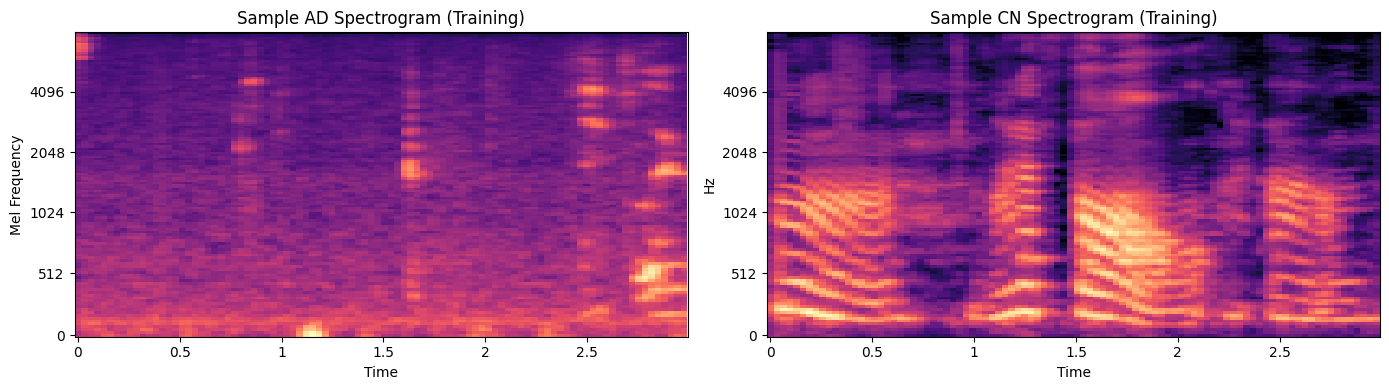

In [8]:
print("\n4️⃣  STANDARDIZING AND EXTRACTING SPECTROGRAMS")
print("-" * 80)

def standardize_segment_length(segment, target_length):
    """Pad or trim to consistent length"""
    if len(segment) < target_length:
        return np.pad(segment, (0, target_length - len(segment)), mode='constant')
    else:
        return segment[:target_length]

def audio_to_melspectrogram(audio, sr=16000, n_mels=128, fmax=8000):
    """Extract Mel spectrogram in dB scale"""
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, fmax=fmax)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

TARGET_LENGTH = int(CONFIG['sr'] * CONFIG['segment_duration'])

# Process TRAINING data
print("Processing training data...")
train_audio = [standardize_segment_length(seg, TARGET_LENGTH) for seg in train_segments]
train_spectrograms = [audio_to_melspectrogram(audio, CONFIG['sr'], CONFIG['n_mels'], CONFIG['fmax'])
                      for audio in train_audio]

# Apply SpecAugment to training spectrograms (additional augmentation)
if CONFIG['use_spec_augment']:
    print("Applying SpecAugment to training spectrograms...")
    train_spectrograms_augmented = []
    for i, spec in enumerate(train_spectrograms):
        # Apply SpecAugment with 50% probability to each spectrogram
        if np.random.rand() > 0.5:
            train_spectrograms_augmented.append(spec_augment(spec))
        else:
            train_spectrograms_augmented.append(spec)
    train_spectrograms = train_spectrograms_augmented

# Process TEST data (NO SpecAugment)
print("Processing test data...")
test_audio = [standardize_segment_length(seg, TARGET_LENGTH) for seg in test_segments]
test_spectrograms = [audio_to_melspectrogram(audio, CONFIG['sr'], CONFIG['n_mels'], CONFIG['fmax'])
                     for audio in test_audio]

# Encode labels
le = LabelEncoder()
le.fit(['AD', 'CN'])  # Ensure consistent encoding

y_train = le.transform(train_labels)
y_test = le.transform(test_labels)

# Convert file groups to numeric IDs for GroupKFold
file_group_encoder = LabelEncoder()
train_file_group_ids = file_group_encoder.fit_transform(train_file_groups)
print(f"  ✓ File groups encoded: {len(file_group_encoder.classes_)} unique files")

# Prepare arrays with channel dimension
X_train = np.array(train_spectrograms)[..., np.newaxis]
X_test = np.array(test_spectrograms)[..., np.newaxis]

print(f"\n✓ Processing complete!")
print(f"  Spectrogram shape: {train_spectrograms[0].shape}")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_train: {len(y_train)} labels")
print(f"  y_test:  {len(y_test)} labels")

# Visualize sample spectrograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ad_idx = list(y_train).index(le.transform(['AD'])[0])
cn_idx = list(y_train).index(le.transform(['CN'])[0])

librosa.display.specshow(train_spectrograms[ad_idx], sr=CONFIG['sr'],
                        x_axis='time', y_axis='mel', fmax=CONFIG['fmax'], ax=axes[0])
axes[0].set_title('Sample AD Spectrogram (Training)', fontsize=12)
axes[0].set_ylabel('Mel Frequency')

librosa.display.specshow(train_spectrograms[cn_idx], sr=CONFIG['sr'],
                        x_axis='time', y_axis='mel', fmax=CONFIG['fmax'], ax=axes[1])
axes[1].set_title('Sample CN Spectrogram (Training)', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Build Model with Regularization

In [9]:
print("\n5️⃣  BUILDING CNN MODEL (IMPROVED ARCHITECTURE)")
print("-" * 80)

def build_cnn_model(input_shape, num_classes=2):
    """
    CNN optimized for small datasets with heavy regularization.

    IMPROVEMENTS:
    - GlobalAveragePooling2D instead of Flatten (drastically reduces params)
    - SpatialDropout2D for better regularization on conv layers
    - L2 regularization on conv layers
    - Smaller dense head to prevent overfitting
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.SpatialDropout2D(0.1),  # Better for conv layers

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.SpatialDropout2D(0.15),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.SpatialDropout2D(0.2),

        # Block 4 (additional depth)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.SpatialDropout2D(0.2),

        # CRITICAL FIX: GlobalAveragePooling2D instead of Flatten
        # Reduces ~2.9M params to ~100K params
        layers.GlobalAveragePooling2D(),

        # Smaller dense head
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_cnn_model(input_shape=X_train.shape[1:])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n📊 Trainable parameters: {trainable_params:,}")
print(f"✓ MUCH smaller than Flatten version (~2.9M → ~{trainable_params//1000}K)")


5️⃣  BUILDING CNN MODEL (IMPROVED ARCHITECTURE)
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 94, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 94, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 47, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 23, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 16, 11, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 8, 5, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             

 Total params: 250,306 (977.76 KB)

 Trainable params: 249,474 (974.51 KB)

 Non-trainable params: 832 (3.25 KB)


📊 Trainable parameters: 249,474
✓ MUCH smaller than Flatten version (~2.9M → ~249K)


## 6. Train Model (with K-Fold Option)

In [10]:
print("\n6️⃣  TRAINING MODEL (WITH GROUPKFOLD - NO DATA LEAKAGE)")
print("-" * 80)

# CRITICAL FIX: Use GroupKFold to split by FILE, not by segment
# This prevents segments from the same file appearing in both fold-train and fold-val

from sklearn.model_selection import GroupKFold

if CONFIG['use_kfold']:
    print(f"Using {CONFIG['n_folds']}-Fold Cross-Validation with GroupKFold")
    print("⚠️  CRITICAL: Splitting by FILE (not segment) to prevent data leakage!")
    print("=" * 80)

    # GroupKFold ensures all segments from one file are in same fold
    group_kfold = GroupKFold(n_splits=CONFIG['n_folds'])
    fold_scores = []
    fold_file_scores = []  # Track file-level scores too

    for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X_train, y_train, groups=train_file_group_ids), 1):
        print(f"\nFOLD {fold}/{CONFIG['n_folds']}")
        print("-" * 40)

        # Verify no file overlap (sanity check)
        train_files_fold = set(train_file_group_ids[train_idx])
        val_files_fold = set(train_file_group_ids[val_idx])
        assert len(train_files_fold & val_files_fold) == 0, "Data leakage detected!"
        print(f"  Train files: {len(train_files_fold)}, Val files: {len(val_files_fold)} (no overlap ✓)")

        # Build fresh model for each fold
        fold_model = build_cnn_model(input_shape=X_train.shape[1:])
        fold_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=0)

        # Train
        fold_history = fold_model.fit(
            X_train[train_idx], y_train[train_idx],
            validation_data=(X_train[val_idx], y_train[val_idx]),
            epochs=CONFIG['epochs'],
            batch_size=CONFIG['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Segment-level accuracy
        val_loss, val_acc = fold_model.evaluate(X_train[val_idx], y_train[val_idx], verbose=0)
        fold_scores.append(val_acc)
        print(f"  Segment Accuracy: {val_acc:.4f}")

        # FILE-LEVEL accuracy (the TRUE metric)
        val_preds_proba = fold_model.predict(X_train[val_idx], verbose=0)
        val_preds = np.argmax(val_preds_proba, axis=1)
        val_true = y_train[val_idx]
        val_groups = train_file_group_ids[val_idx]

        # Aggregate by file
        file_preds = {}
        file_true = {}
        for i, group_id in enumerate(val_groups):
            if group_id not in file_preds:
                file_preds[group_id] = []
                file_true[group_id] = val_true[i]  # All segments from same file have same label
            file_preds[group_id].append(val_preds_proba[i])

        # Majority vote / mean probability for each file
        file_correct = 0
        for group_id in file_preds:
            avg_proba = np.mean(file_preds[group_id], axis=0)
            file_pred = np.argmax(avg_proba)
            if file_pred == file_true[group_id]:
                file_correct += 1

        file_acc = file_correct / len(file_preds)
        fold_file_scores.append(file_acc)
        print(f"  FILE-LEVEL Accuracy: {file_acc:.4f} ({file_correct}/{len(file_preds)} files)")

    print("\n" + "=" * 80)
    print("CROSS-VALIDATION RESULTS:")
    print(f"  Segment-Level:  Mean={np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
    print(f"  FILE-LEVEL:     Mean={np.mean(fold_file_scores):.4f} (±{np.std(fold_file_scores):.4f}) ← TRUE METRIC")
    print("=" * 80)

    # Train final model on ALL training data
    print("\nTraining final model on full training set...")

    model = build_cnn_model(input_shape=X_train.shape[1:])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                              restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=7, min_lr=1e-7, verbose=1)

    # Use a small validation split from training (not ideal but needed for early stopping)
    # This will have some segment overlap but final eval is on held-out test set
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

else:
    # Simple training with validation split
    print("Training with validation split (20% of training data)...")

    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                              restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=7, min_lr=1e-7, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )


6️⃣  TRAINING MODEL (WITH GROUPKFOLD - NO DATA LEAKAGE)
--------------------------------------------------------------------------------
Using 5-Fold Cross-Validation with GroupKFold
⚠️  CRITICAL: Splitting by FILE (not segment) to prevent data leakage!

FOLD 1/5
----------------------------------------
  Train files: 102, Val files: 26 (no overlap ✓)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Segment Accuracy: 0.6340
  FILE-LEVEL Accuracy: 0.7692 (20/26 files)

FOLD 2/5
----------------------------------------
  Train files: 103, Val files: 25 (no overlap ✓)
  Segment Accuracy: 0.6662
  FILE-LEVEL Accuracy: 0.7200 (18/25 files)

FOLD 3/5
----------------------------------------
  Train files: 102, Val files: 26 (no overlap ✓)
  Segment Accuracy: 0.5027
  FILE-LEVEL Accuracy: 0.4231 (11/26 files)

FOLD 4/5
----------------------------------------
  Train files: 103, Val files: 25 (no overlap ✓)
  Segment Accuracy: 0.5638
  FILE-LEVEL Accuracy: 0.6800 (17/25 files)

FOLD 5/5
----------------------------------------
  Train files: 102, Val files: 26 (no overlap ✓)
  Segment Accuracy: 0.4794
  FILE-LEVEL Accuracy: 0.4615 (12/26 files)

CROSS-VALIDATION RESULTS:
  Segment-Level:  Mean=0.5692 (±0.0723)
  FILE-LEVEL:     Mean=0.6108 (±0.1409) ← TRUE METRIC

Training final model on full training set...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.5139 - lo

## 7. Evaluate on Held-Out Test Set


7️⃣  EVALUATION ON HELD-OUT TEST SET
⚠️  Test set contains segments from FILES not seen during training!
    This is a TRUE evaluation without data leakage.

📊 SEGMENT-LEVEL Metrics (for reference only):
   Accuracy: 0.5590 (55.90%)

🎯 FILE-LEVEL EVALUATION (TRUE CLINICAL METRIC)

📊 File-Level Accuracy by Aggregation Strategy:
   mean_prob      : 0.5455 (54.55%) - 18/33 files
   median_prob    : 0.5455 (54.55%) - 18/33 files
   majority_vote  : 0.5152 (51.52%) - 17/33 files

🎯 FINAL FILE-LEVEL ACCURACY: 0.5455 (54.55%)
   (Using mean probability aggregation)

--------------------------------------------------------------------------------
Classification Report (FILE-LEVEL):
              precision    recall  f1-score   support

          AD     0.6154    0.4444    0.5161        18
          CN     0.5000    0.6667    0.5714        15

    accuracy                         0.5455        33
   macro avg     0.5577    0.5556    0.5438        33
weighted avg     0.5629    0.5455    0.5413 

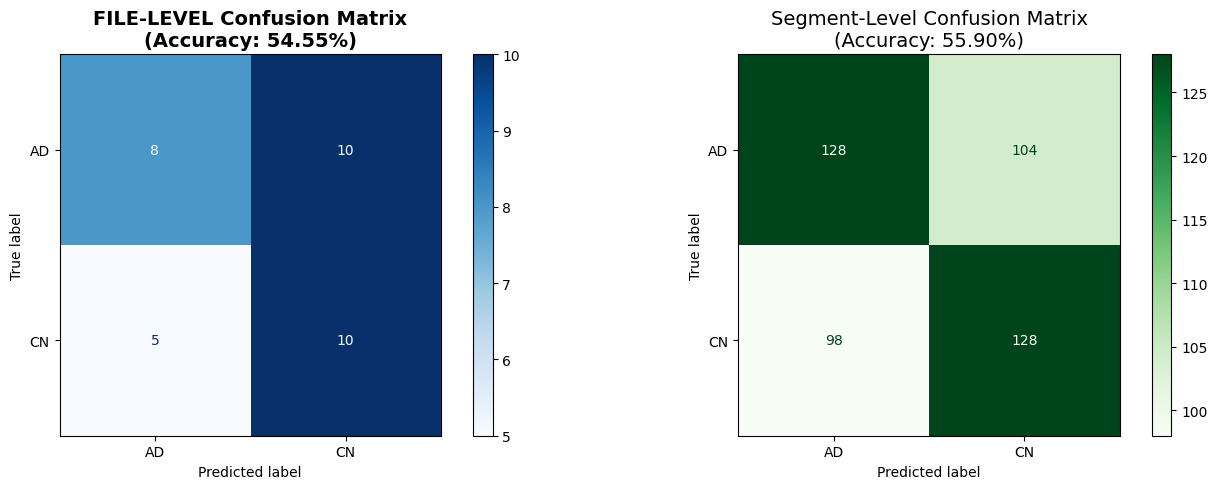


📋 Per-File Predictions:
------------------------------------------------------------
  adrso300.wav         | True: CN | Pred: AD |  9 segs | ✗
  adrso187.wav         | True: AD | Pred: CN | 12 segs | ✗
  adrso280.wav         | True: CN | Pred: AD | 20 segs | ✗
  adrso299.wav         | True: CN | Pred: CN | 13 segs | ✓
  adrso169.wav         | True: CN | Pred: CN |  9 segs | ✓
  adrso002.wav         | True: CN | Pred: AD | 18 segs | ✗
  adrso110.wav         | True: AD | Pred: CN | 13 segs | ✗
  adrso027.wav         | True: AD | Pred: CN | 12 segs | ✗
  adrso205.wav         | True: AD | Pred: CN | 13 segs | ✗
  adrso232.wav         | True: AD | Pred: AD | 12 segs | ✓
  adrso014.wav         | True: CN | Pred: CN | 12 segs | ✓
  adrso078.wav         | True: AD | Pred: CN |  9 segs | ✗
  adrso017.wav         | True: CN | Pred: CN | 16 segs | ✓
  adrso070.wav         | True: AD | Pred: AD | 11 segs | ✓
  adrso246.wav         | True: AD | Pred: CN |  8 segs | ✗
  adrso285.wav         | True

In [11]:
print("\n7️⃣  EVALUATION ON HELD-OUT TEST SET")
print("=" * 80)
print("⚠️  Test set contains segments from FILES not seen during training!")
print("    This is a TRUE evaluation without data leakage.\n")

# SEGMENT-LEVEL evaluation (for reference)
y_pred_proba_test = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba_test, axis=1)
test_acc_segment = accuracy_score(y_test, y_pred)

print(f"📊 SEGMENT-LEVEL Metrics (for reference only):")
print(f"   Accuracy: {test_acc_segment:.4f} ({test_acc_segment*100:.2f}%)")

# =============================================================================
# FILE-LEVEL EVALUATION (THE TRUE METRIC!)
# =============================================================================
print("\n" + "=" * 80)
print("🎯 FILE-LEVEL EVALUATION (TRUE CLINICAL METRIC)")
print("=" * 80)

# Aggregate predictions by file using mean probability
file_predictions_agg = {}  # file -> list of prediction probabilities
file_true_labels = {}      # file -> true label

for i, filename in enumerate(test_file_groups):
    if filename not in file_predictions_agg:
        file_predictions_agg[filename] = []
        file_true_labels[filename] = y_test[i]
    file_predictions_agg[filename].append(y_pred_proba_test[i])

# Compute file-level predictions using multiple strategies
strategies = {
    'mean_prob': [],      # Mean probability (recommended)
    'median_prob': [],    # Median probability
    'majority_vote': [],  # Majority vote
}
file_true_array = []
file_names_order = []

for filename in file_predictions_agg:
    proba_list = np.array(file_predictions_agg[filename])
    true_label = file_true_labels[filename]

    file_true_array.append(true_label)
    file_names_order.append(filename)

    # Mean probability (recommended)
    mean_proba = np.mean(proba_list, axis=0)
    strategies['mean_prob'].append(np.argmax(mean_proba))

    # Median probability
    median_proba = np.median(proba_list, axis=0)
    strategies['median_prob'].append(np.argmax(median_proba))

    # Majority vote
    segment_votes = np.argmax(proba_list, axis=1)
    majority_vote = Counter(segment_votes).most_common(1)[0][0]
    strategies['majority_vote'].append(majority_vote)

file_true_array = np.array(file_true_array)

print(f"\n📊 File-Level Accuracy by Aggregation Strategy:")
for strategy_name, preds in strategies.items():
    preds_array = np.array(preds)
    acc = accuracy_score(file_true_array, preds_array)
    print(f"   {strategy_name:15s}: {acc:.4f} ({acc*100:.2f}%) - {np.sum(preds_array == file_true_array)}/{len(file_true_array)} files")

# Use mean_prob as the main file-level prediction
y_pred_file = np.array(strategies['mean_prob'])
y_true_file = file_true_array
test_acc = accuracy_score(y_true_file, y_pred_file)

print(f"\n🎯 FINAL FILE-LEVEL ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   (Using mean probability aggregation)")

print("\n" + "-" * 80)
print("Classification Report (FILE-LEVEL):")
print(classification_report(y_true_file, y_pred_file, target_names=le.classes_, digits=4))

# Confusion Matrix (FILE-LEVEL)
cm = confusion_matrix(y_true_file, y_pred_file)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# File-level confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[0])
axes[0].set_title(f'FILE-LEVEL Confusion Matrix\n(Accuracy: {test_acc:.2%})', fontsize=14, fontweight='bold')

# Segment-level confusion matrix (for comparison)
cm_segment = confusion_matrix(y_test, y_pred)
disp_seg = ConfusionMatrixDisplay(confusion_matrix=cm_segment, display_labels=le.classes_)
disp_seg.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[1])
axes[1].set_title(f'Segment-Level Confusion Matrix\n(Accuracy: {test_acc_segment:.2%})', fontsize=14)

plt.tight_layout()
plt.show()

# Per-file details
print("\n📋 Per-File Predictions:")
print("-" * 60)
for i, filename in enumerate(file_names_order):
    true_lbl = le.inverse_transform([y_true_file[i]])[0]
    pred_lbl = le.inverse_transform([y_pred_file[i]])[0]
    n_segs = len(file_predictions_agg[filename])
    correct = "✓" if y_true_file[i] == y_pred_file[i] else "✗"
    print(f"  {filename:20s} | True: {true_lbl} | Pred: {pred_lbl} | {n_segs:2d} segs | {correct}")

## 7.1 Advanced Model Evaluation Metrics

In [12]:
print("\n📊 ADVANCED MODEL EVALUATION METRICS (FILE-LEVEL)")
print("=" * 80)

from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score)
from sklearn.calibration import calibration_curve

# Compute FILE-LEVEL probabilities (mean aggregation)
file_proba_agg = {}
for filename in file_predictions_agg:
    proba_list = np.array(file_predictions_agg[filename])
    file_proba_agg[filename] = np.mean(proba_list, axis=0)

# Build arrays for file-level metrics
y_scores_file = np.array([file_proba_agg[f] for f in file_names_order])

print(f"Classes: {le.classes_}")
print(f"Class 0: {le.classes_[0]}, Class 1: {le.classes_[1]}")

# Get probabilities for the positive class (AD)
ad_class_idx = list(le.classes_).index('AD') if 'AD' in le.classes_ else 0
y_scores = y_scores_file[:, ad_class_idx]  # FILE-LEVEL probability of AD class

# Create binary labels (1 for AD, 0 for CN)
y_true_binary = (y_true_file == ad_class_idx).astype(int)
y_pred_binary = (y_pred_file == ad_class_idx).astype(int)

print(f"\n📊 FILE-LEVEL evaluation:")
print(f"   Total test files: {len(y_true_file)}")
print(f"   AD files: {np.sum(y_true_binary)}, CN files: {np.sum(1-y_true_binary)}")


📊 ADVANCED MODEL EVALUATION METRICS (FILE-LEVEL)
Classes: ['AD' 'CN']
Class 0: AD, Class 1: CN

📊 FILE-LEVEL evaluation:
   Total test files: 33
   AD files: 18, CN files: 15


### ROC Curve and AUC


📈 ROC CURVE AND AUC
--------------------------------------------------


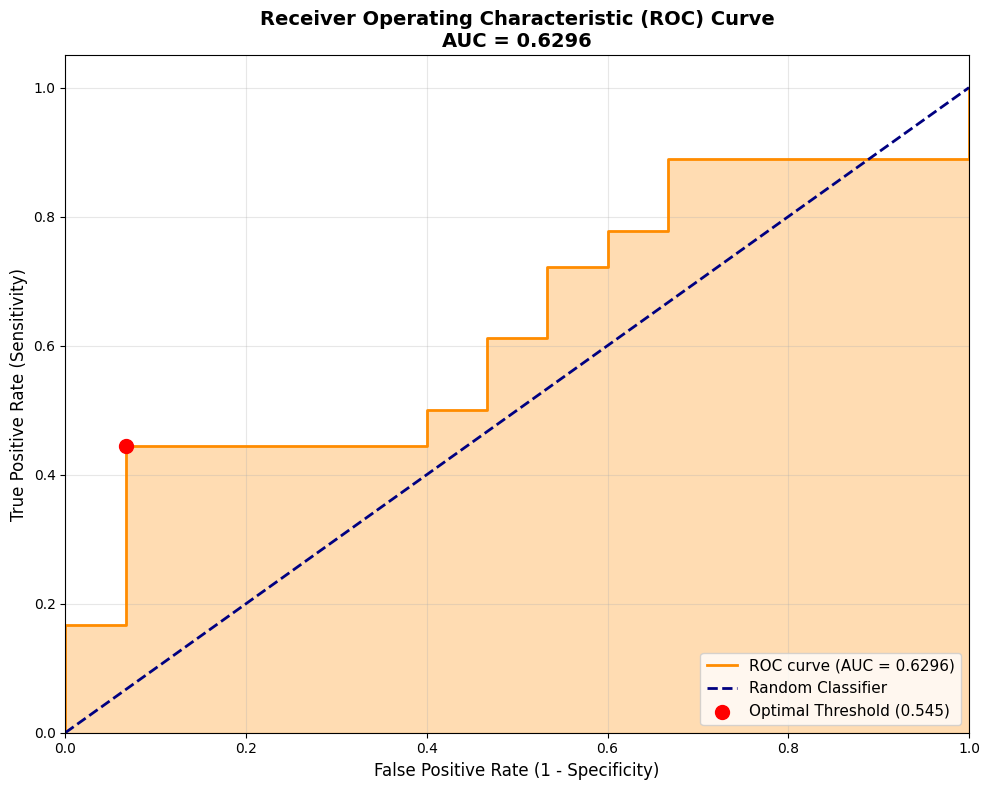

✓ AUC-ROC Score: 0.6296
✓ Optimal Threshold (Youden's J): 0.5446


In [13]:
# ROC Curve
print("\n📈 ROC CURVE AND AUC")
print("-" * 50)

fpr, tpr, thresholds_roc = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.3, color='darkorange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Receiver Operating Characteristic (ROC) Curve\nAUC = {roc_auc:.4f}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

# Add optimal threshold point (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds_roc[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100,
            label=f'Optimal Threshold ({optimal_threshold:.3f})', zorder=5)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ AUC-ROC Score: {roc_auc:.4f}")
print(f"✓ Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

### Precision-Recall (PR) Curve


📉 PRECISION-RECALL CURVE
--------------------------------------------------


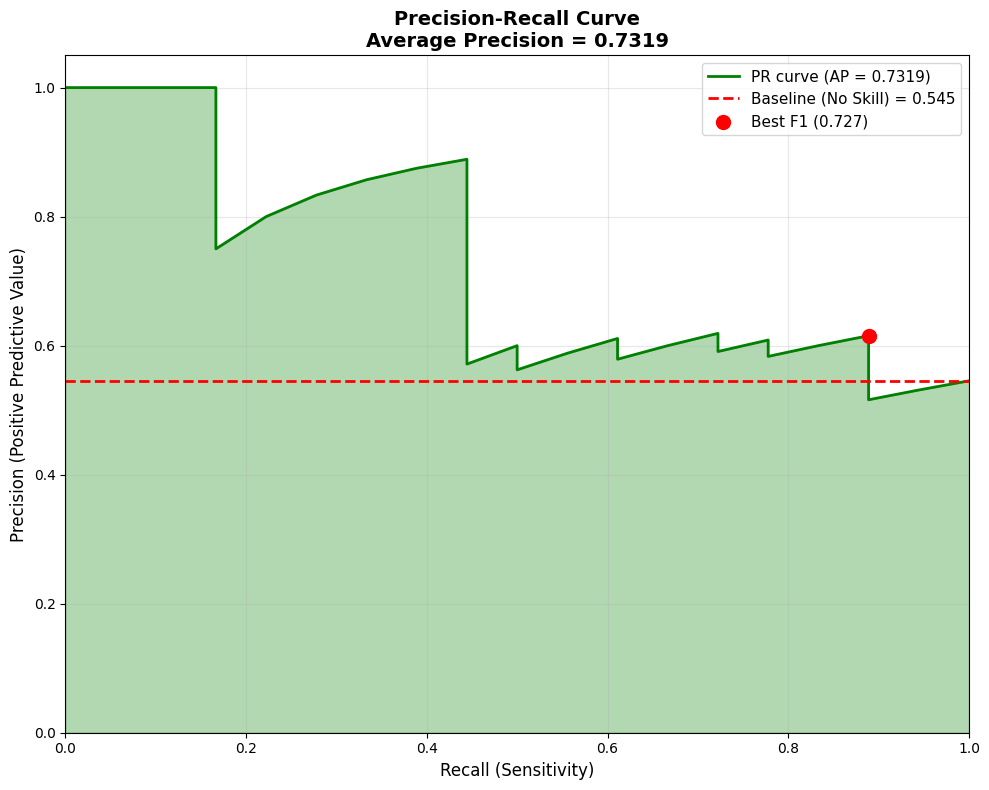

✓ Average Precision (AP) Score: 0.7319
✓ Best F1 Score: 0.7273


In [14]:
# Precision-Recall Curve
print("\n📉 PRECISION-RECALL CURVE")
print("-" * 50)

precision, recall, thresholds_pr = precision_recall_curve(y_true_binary, y_scores)
avg_precision = average_precision_score(y_true_binary, y_scores)

# Calculate baseline (proportion of positive class)
baseline = np.sum(y_true_binary) / len(y_true_binary)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.axhline(y=baseline, color='red', linestyle='--', lw=2, label=f'Baseline (No Skill) = {baseline:.3f}')
plt.fill_between(recall, precision, alpha=0.3, color='green')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title(f'Precision-Recall Curve\nAverage Precision = {avg_precision:.4f}', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)

# Find threshold for best F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1_idx = np.argmax(f1_scores[:-1])  # Exclude last value (recall=0)
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], marker='o', color='red', s=100,
            label=f'Best F1 ({f1_scores[best_f1_idx]:.3f})', zorder=5)
plt.legend(loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ Average Precision (AP) Score: {avg_precision:.4f}")
print(f"✓ Best F1 Score: {f1_scores[best_f1_idx]:.4f}")

### Sensitivity and Specificity Analysis


🔬 SENSITIVITY / SPECIFICITY ANALYSIS
--------------------------------------------------

📊 Confusion Matrix Components:
   True Positives (TP):  8
   True Negatives (TN):  10
   False Positives (FP): 5
   False Negatives (FN): 10

📈 Performance Metrics (AD as positive class):
   Sensitivity (Recall/TPR):     0.4444 (44.44%)
   Specificity (TNR):            0.6667 (66.67%)
   Precision (PPV):              0.6154 (61.54%)
   Negative Predictive Value:    0.5000 (50.00%)
   F1 Score:                     0.5161
   Balanced Accuracy:            0.5556 (55.56%)


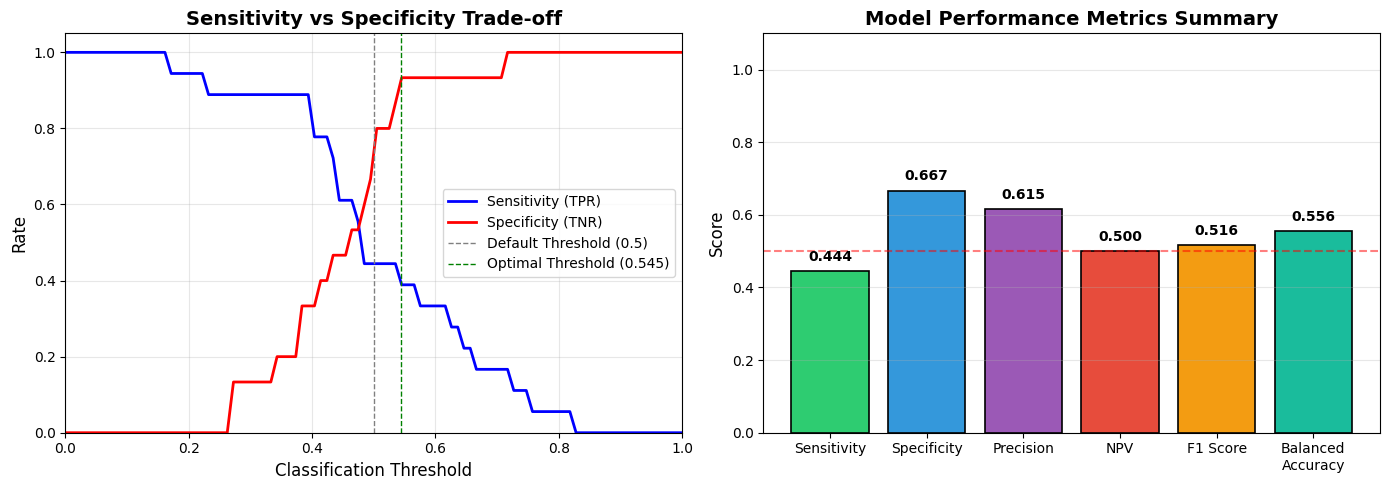

In [15]:
# Sensitivity and Specificity Analysis
print("\n🔬 SENSITIVITY / SPECIFICITY ANALYSIS")
print("-" * 50)

# Calculate confusion matrix components
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_binary, y_pred_binary)
TN, FP, FN, TP = cm.ravel()

# Calculate metrics
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (Recall)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0          # Positive Predictive Value (Precision)
npv = TN / (TN + FN) if (TN + FN) > 0 else 0          # Negative Predictive Value
f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else 0
balanced_acc = (sensitivity + specificity) / 2

print(f"\n📊 Confusion Matrix Components:")
print(f"   True Positives (TP):  {TP}")
print(f"   True Negatives (TN):  {TN}")
print(f"   False Positives (FP): {FP}")
print(f"   False Negatives (FN): {FN}")

print(f"\n📈 Performance Metrics (AD as positive class):")
print(f"   Sensitivity (Recall/TPR):     {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"   Specificity (TNR):            {specificity:.4f} ({specificity*100:.2f}%)")
print(f"   Precision (PPV):              {ppv:.4f} ({ppv*100:.2f}%)")
print(f"   Negative Predictive Value:    {npv:.4f} ({npv*100:.2f}%)")
print(f"   F1 Score:                     {f1:.4f}")
print(f"   Balanced Accuracy:            {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")

# Sensitivity vs Specificity trade-off plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sensitivity and Specificity at different thresholds
thresholds_plot = np.linspace(0, 1, 100)
sensitivities = []
specificities = []

for thresh in thresholds_plot:
    y_pred_thresh = (y_scores >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_true_binary, y_pred_thresh, labels=[0, 1])
    if cm_thresh.shape == (2, 2):
        tn, fp, fn, tp = cm_thresh.ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        sens = 0
        spec = 0
    sensitivities.append(sens)
    specificities.append(spec)

axes[0].plot(thresholds_plot, sensitivities, 'b-', lw=2, label='Sensitivity (TPR)')
axes[0].plot(thresholds_plot, specificities, 'r-', lw=2, label='Specificity (TNR)')
axes[0].axvline(x=0.5, color='gray', linestyle='--', lw=1, label='Default Threshold (0.5)')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', lw=1, label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('Classification Threshold', fontsize=12)
axes[0].set_ylabel('Rate', fontsize=12)
axes[0].set_title('Sensitivity vs Specificity Trade-off', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Plot 2: Bar chart of metrics
metrics_names = ['Sensitivity', 'Specificity', 'Precision', 'NPV', 'F1 Score', 'Balanced\nAccuracy']
metrics_values = [sensitivity, specificity, ppv, npv, f1, balanced_acc]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

bars = axes[1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Model Performance Metrics Summary', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Calibration Analysis


📐 CALIBRATION ANALYSIS
--------------------------------------------------


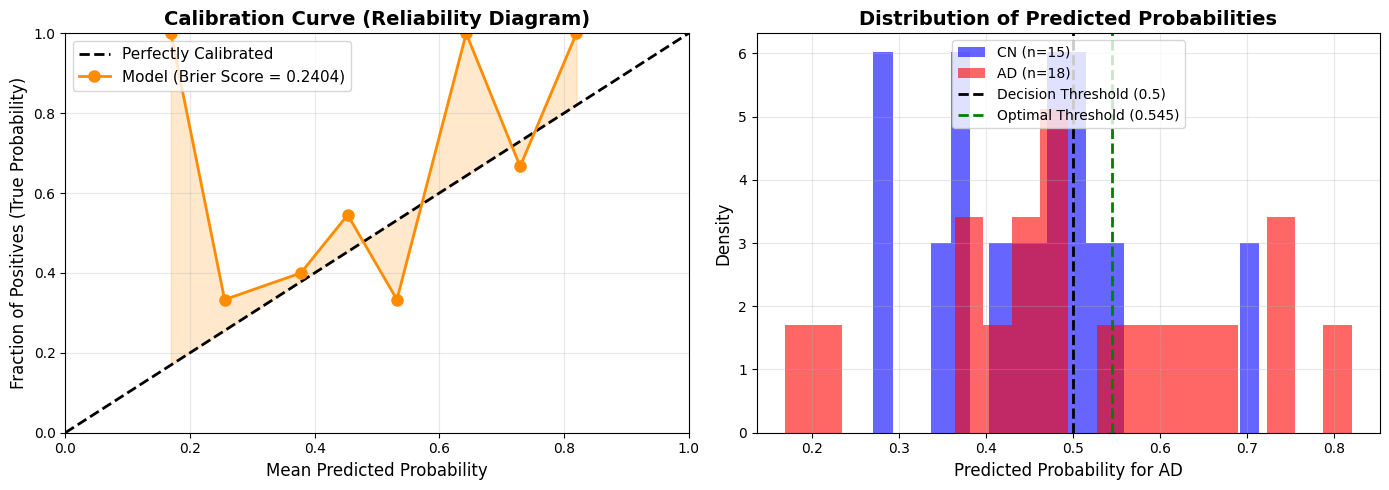


📊 Calibration Metrics:
   Brier Score: 0.2404 (0 = perfect, 0.25 = random)
   Expected Calibration Error (ECE): 0.1769

   Calibration Quality: Fair

💡 Interpretation:
   - Brier Score measures the mean squared error between predicted
     probabilities and actual outcomes (lower = better)
   - A well-calibrated model's curve should follow the diagonal
   - Curves above diagonal: model underestimates probability
   - Curves below diagonal: model overestimates probability


In [16]:
# Calibration Analysis
print("\n📐 CALIBRATION ANALYSIS")
print("-" * 50)

from sklearn.metrics import brier_score_loss

# Calculate calibration curve
n_bins = 10
prob_true, prob_pred = calibration_curve(y_true_binary, y_scores, n_bins=n_bins, strategy='uniform')

# Calculate Brier Score (lower is better)
brier_score = brier_score_loss(y_true_binary, y_scores)

# Expected Calibration Error (ECE)
bin_counts = np.histogram(y_scores, bins=n_bins, range=(0, 1))[0]
ece = np.sum(np.abs(prob_true - prob_pred) * bin_counts[:len(prob_true)]) / np.sum(bin_counts[:len(prob_true)]) if len(prob_true) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calibration Curve (Reliability Diagram)
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Perfectly Calibrated')
axes[0].plot(prob_pred, prob_true, 'o-', color='darkorange', lw=2, markersize=8,
             label=f'Model (Brier Score = {brier_score:.4f})')
axes[0].fill_between(prob_pred, prob_true, prob_pred, alpha=0.2, color='darkorange')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[0].set_ylabel('Fraction of Positives (True Probability)', fontsize=12)
axes[0].set_title('Calibration Curve (Reliability Diagram)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Plot 2: Prediction Distribution with Calibration Info
axes[1].hist(y_scores[y_true_binary == 0], bins=20, alpha=0.6, color='blue',
             label=f'CN (n={np.sum(y_true_binary == 0)})', density=True)
axes[1].hist(y_scores[y_true_binary == 1], bins=20, alpha=0.6, color='red',
             label=f'AD (n={np.sum(y_true_binary == 1)})', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=2, label='Decision Threshold (0.5)')
axes[1].axvline(x=optimal_threshold, color='green', linestyle='--', lw=2,
                label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[1].set_xlabel('Predicted Probability for AD', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper center', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Calibration Metrics:")
print(f"   Brier Score: {brier_score:.4f} (0 = perfect, 0.25 = random)")
print(f"   Expected Calibration Error (ECE): {ece:.4f}")

# Interpretation
if brier_score < 0.1:
    calibration_quality = "Excellent"
elif brier_score < 0.2:
    calibration_quality = "Good"
elif brier_score < 0.25:
    calibration_quality = "Fair"
else:
    calibration_quality = "Poor"

print(f"\n   Calibration Quality: {calibration_quality}")
print(f"\n💡 Interpretation:")
print(f"   - Brier Score measures the mean squared error between predicted")
print(f"     probabilities and actual outcomes (lower = better)")
print(f"   - A well-calibrated model's curve should follow the diagonal")
print(f"   - Curves above diagonal: model underestimates probability")
print(f"   - Curves below diagonal: model overestimates probability")

### Combined ROC and PR Curves with Summary


📊 COMPREHENSIVE EVALUATION SUMMARY


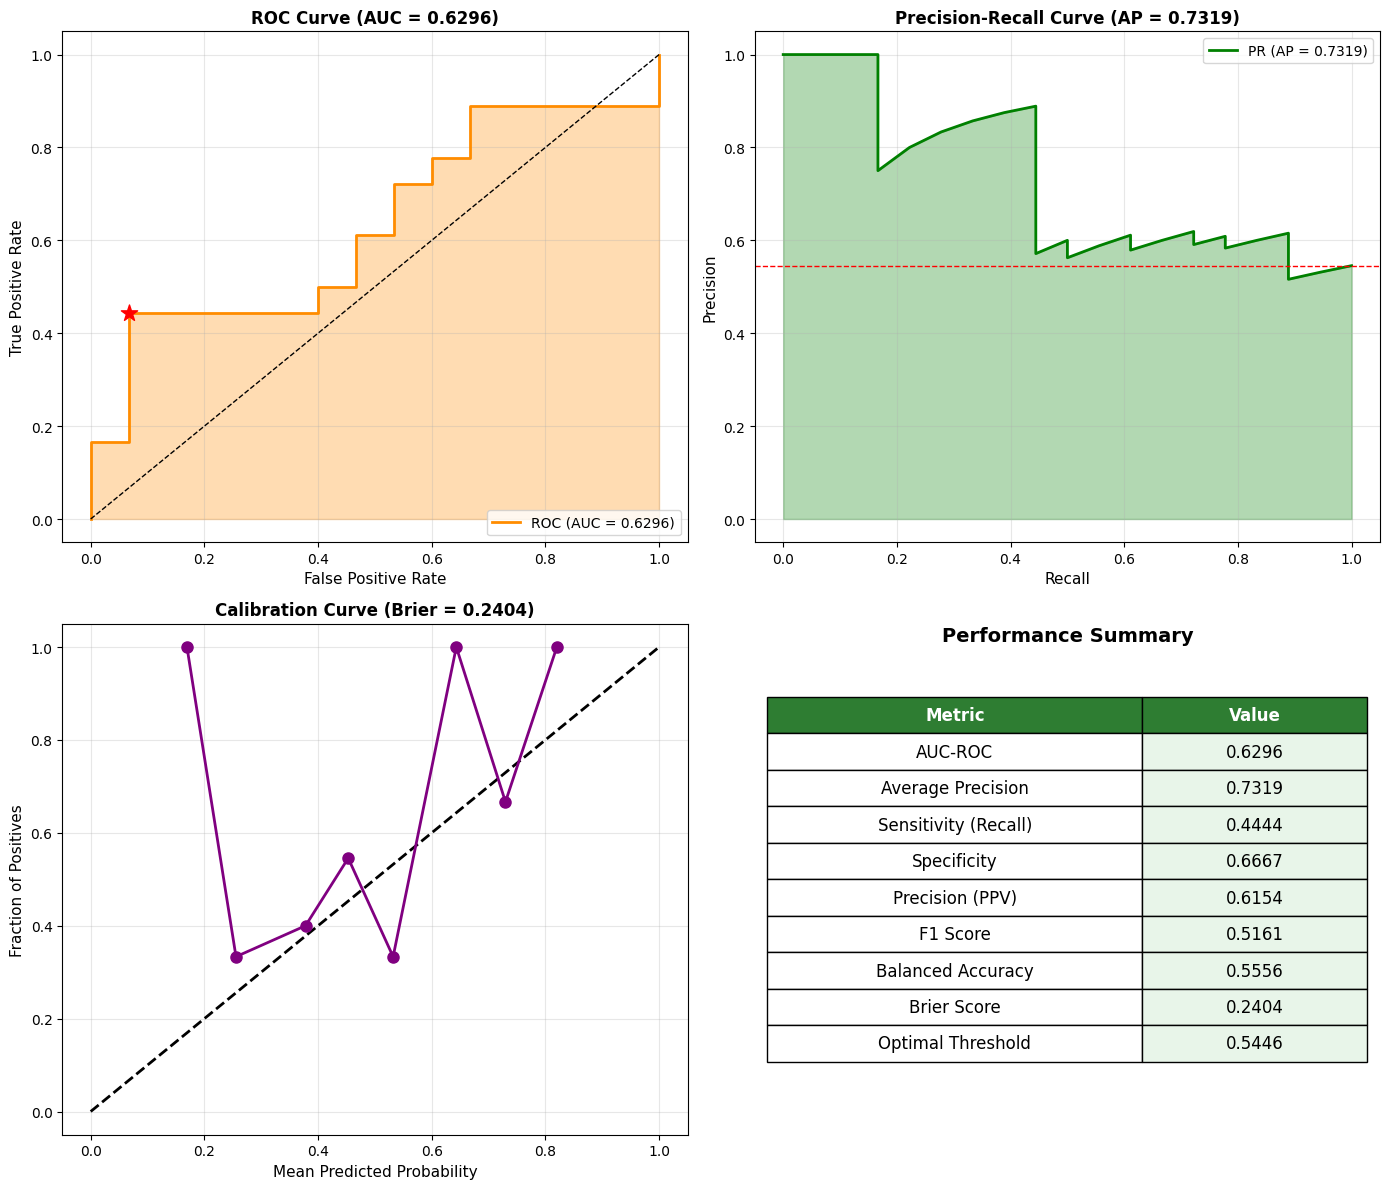


✅ Evaluation Summary:
   • AUC-ROC: 0.6296 - Poor
   • Average Precision: 0.7319
   • Sensitivity: 0.4444 (ability to detect AD)
   • Specificity: 0.6667 (ability to identify CN)
   • Calibration: Fair

💾 Summary plot saved to: model_evaluation_summary.png


In [17]:
# Combined Summary Plot
print("\n📊 COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: ROC Curve
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[0, 0].scatter(fpr[optimal_idx], tpr[optimal_idx], marker='*', color='red', s=150, zorder=5)
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: PR Curve
axes[0, 1].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {avg_precision:.4f})')
axes[0, 1].axhline(y=baseline, color='red', linestyle='--', lw=1)
axes[0, 1].fill_between(recall, precision, alpha=0.3, color='green')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title(f'Precision-Recall Curve (AP = {avg_precision:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Calibration Curve
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1, 0].plot(prob_pred, prob_true, 'o-', color='purple', lw=2, markersize=8)
axes[1, 0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[1, 0].set_ylabel('Fraction of Positives', fontsize=11)
axes[1, 0].set_title(f'Calibration Curve (Brier = {brier_score:.4f})', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Summary Metrics Table
axes[1, 1].axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['AUC-ROC', f'{roc_auc:.4f}'],
    ['Average Precision', f'{avg_precision:.4f}'],
    ['Sensitivity (Recall)', f'{sensitivity:.4f}'],
    ['Specificity', f'{specificity:.4f}'],
    ['Precision (PPV)', f'{ppv:.4f}'],
    ['F1 Score', f'{f1:.4f}'],
    ['Balanced Accuracy', f'{balanced_acc:.4f}'],
    ['Brier Score', f'{brier_score:.4f}'],
    ['Optimal Threshold', f'{optimal_threshold:.4f}']
]

table = axes[1, 1].table(cellText=summary_data[1:], colLabels=summary_data[0],
                          loc='center', cellLoc='center',
                          colColours=['#4CAF50', '#4CAF50'],
                          colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Style header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#2E7D32')
    else:
        if col == 1:
            cell.set_facecolor('#E8F5E9')

axes[1, 1].set_title('Performance Summary', fontsize=14, fontweight='bold', y=0.95)

plt.tight_layout()
plt.savefig('model_evaluation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Evaluation Summary:")
print(f"   • AUC-ROC: {roc_auc:.4f} - {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'}")
print(f"   • Average Precision: {avg_precision:.4f}")
print(f"   • Sensitivity: {sensitivity:.4f} (ability to detect AD)")
print(f"   • Specificity: {specificity:.4f} (ability to identify CN)")
print(f"   • Calibration: {calibration_quality}")
print(f"\n💾 Summary plot saved to: model_evaluation_summary.png")

## 8. Visualize Training History


8️⃣  TRAINING HISTORY
--------------------------------------------------------------------------------


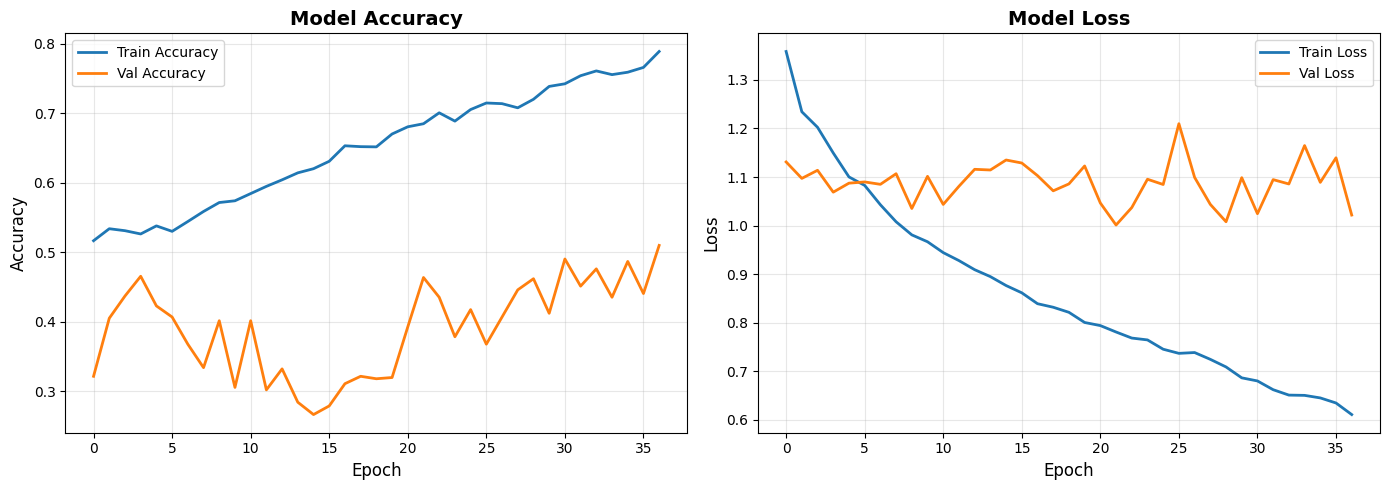

In [18]:
print("\n8️⃣  TRAINING HISTORY")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Load and Predict on Test-Dist Data

In [19]:
print("\n9️⃣  PREDICTIONS ON TEST-DIST DATA (WITH PAR SEGMENTATION)")
print("=" * 80)

def load_test_segmented_audio(audio_folder, seg_folder, sr=16000, speaker='PAR', min_duration=1.0):
    """
    Load test audio files using PAR segmentation for consistency with training.
    Returns segments grouped by file ID for aggregated predictions.
    """
    all_segments = []  # (segment, file_id)
    file_ids_unique = []

    audio_files = sorted([f for f in os.listdir(audio_folder) if f.endswith('.wav')])

    for filename in audio_files:
        audio_path = os.path.join(audio_folder, filename)
        file_id = os.path.splitext(filename)[0]

        # Find matching segmentation file (adrsdt*.csv format)
        seg_filename = file_id + '.csv'
        seg_path = os.path.join(seg_folder, seg_filename)

        if os.path.exists(seg_path):
            try:
                seg_df = pd.read_csv(seg_path)
                y_full, _ = librosa.load(audio_path, sr=sr)

                # Extract PAR segments
                par_segments = seg_df[seg_df['speaker'] == speaker]

                for _, row in par_segments.iterrows():
                    begin_sample = int(row['begin'] * sr / 1000)
                    end_sample = int(row['end'] * sr / 1000)
                    segment = y_full[begin_sample:end_sample]

                    if len(segment) > sr * min_duration:
                        segment = librosa.util.normalize(segment)
                        all_segments.append((segment, file_id))

                if file_id not in file_ids_unique:
                    file_ids_unique.append(file_id)

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
        else:
            # No segmentation file - load full audio
            try:
                y, _ = librosa.load(audio_path, sr=sr)
                y = librosa.util.normalize(y)
                all_segments.append((y, file_id))
                if file_id not in file_ids_unique:
                    file_ids_unique.append(file_id)
            except Exception as e:
                print(f"  Error loading {filename}: {e}")

    return all_segments, file_ids_unique

# Load test audio with segmentation
test_segments, test_ids = load_test_segmented_audio(
    CONFIG['test_folder'],
    CONFIG['test_seg_folder'],
    CONFIG['sr'],
    min_duration=CONFIG['min_segment_duration']
)

print(f"Loaded {len(test_segments)} PAR segments from {len(test_ids)} test files")

# Standardize segment lengths
test_audio_standardized = [
    standardize_segment_length(seg, TARGET_LENGTH)
    for seg, _ in test_segments
]

# Extract spectrograms
test_spectrograms = [
    audio_to_melspectrogram(audio, CONFIG['sr'], CONFIG['n_mels'], CONFIG['fmax'])
    for audio in test_audio_standardized
]

X_test_dist = np.array(test_spectrograms)[..., np.newaxis]
print(f"Test data shape: {X_test_dist.shape}")

# Make predictions
y_pred_proba = model.predict(X_test_dist, verbose=0)
y_pred_segments = np.argmax(y_pred_proba, axis=1)

# Aggregate predictions by file (majority voting with confidence)
print("\nAggregating segment predictions per file...")
file_predictions = {}
file_confidences = {}

for i, (_, file_id) in enumerate(test_segments):
    if file_id not in file_predictions:
        file_predictions[file_id] = []
        file_confidences[file_id] = []
    file_predictions[file_id].append(y_pred_segments[i])
    file_confidences[file_id].append(y_pred_proba[i])

# Final prediction per file using majority voting
final_predictions = {}
final_confidences = {}

for file_id in test_ids:
    preds = file_predictions[file_id]
    confs = file_confidences[file_id]

    # Majority vote
    pred_counts_file = Counter(preds)
    final_pred = pred_counts_file.most_common(1)[0][0]
    final_predictions[file_id] = final_pred

    # Average confidence for the winning class
    avg_conf = np.mean([confs[i][final_pred] for i in range(len(preds)) if preds[i] == final_pred])
    final_confidences[file_id] = avg_conf

y_pred_labels = [le.inverse_transform([final_predictions[fid]])[0] for fid in test_ids]

# Show prediction distribution
print("\nPrediction Distribution (per file):")
pred_counts = Counter(y_pred_labels)
for label, count in pred_counts.items():
    print(f"  {label}: {count} files ({count/len(y_pred_labels)*100:.1f}%)")

# Show sample predictions
print("\nSample Predictions (first 10):")
for i in range(min(10, len(test_ids))):
    fid = test_ids[i]
    n_segs = len(file_predictions[fid])
    print(f"  {fid}: {y_pred_labels[i]} (confidence: {final_confidences[fid]:.2%}, {n_segs} segments)")


9️⃣  PREDICTIONS ON TEST-DIST DATA (WITH PAR SEGMENTATION)
Loaded 860 PAR segments from 71 test files
Test data shape: (860, 128, 94, 1)

Aggregating segment predictions per file...


KeyError: 'adrsdt49'

## 10. Save Predictions to CSV

In [ ]:
print("\n🔟 SAVING PREDICTIONS")
print("-" * 80)

# Convert to lowercase (ad/cn format)
predictions_lower = [label.lower() for label in y_pred_labels]

results_df = pd.DataFrame({
    'ID': test_ids,
    'Prediction': predictions_lower
})

# Sort by ID
results_df = results_df.sort_values('ID').reset_index(drop=True)

# Save
output_path = 'test-dist/my_predictions_task1.csv'
results_df.to_csv(output_path, index=False)
print(f"✓ Predictions saved to: {output_path}")

# Display all predictions
print("\nAll Predictions:")
print(results_df.to_string(index=False, max_rows=20))
if len(results_df) > 20:
    print(f"... ({len(results_df) - 20} more rows)")

## 11. Save Model and Preprocessing Parameters

In [ ]:
print("\n1️⃣1️⃣  SAVING MODEL AND PARAMETERS")
print("-" * 80)

# Save model
model.save('alzheimers_cnn_model_improved.keras')
print("✓ Model saved: alzheimers_cnn_model_improved.keras")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder saved: label_encoder.pkl")

# Save preprocessing parameters
preprocessing_params = {
    'sr': CONFIG['sr'],
    'segment_duration': CONFIG['segment_duration'],
    'n_mels': CONFIG['n_mels'],
    'fmax': CONFIG['fmax'],
    'target_length': TARGET_LENGTH,
    'spectrogram_shape': train_spectrograms[0].shape  # Use train_spectrograms
}
with open('preprocessing_params.pkl', 'wb') as f:
    pickle.dump(preprocessing_params, f)
print("✓ Preprocessing params saved: preprocessing_params.pkl")

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLETE!")
print("=" * 80)
print(f"Final Test Accuracy: {test_acc:.2%}")
print(f"Total Training Segments: {len(X_train)}")
print(f"Total Test Segments: {len(X_test)}")
print(f"Test Predictions: {len(test_ids)} files")
print("=" * 80)
print("\n🛡️  DATA INTEGRITY:")
print("   • File-level split: Speakers in test never seen during training")
print("   • Augmentation: Applied ONLY to training data")
print("   • No data leakage between train and test sets")